------------------
Here I make some code that handles the atomic $N_\eta=3$ parton-mean field system for generic anisotropy $\alpha$
------------------
I would like to calulate $\langle \hat{Q} \rangle $, $\langle \hat{L}^2_{(\pm)}\rangle$ as well as have a way to check the cutoff dependence


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
import matplotlib as mpl
import scipy.sparse as sparse
from scipy.sparse.linalg import eigsh
import time
import pickle
from dataclasses import dataclass
from typing import Tuple
from scipy.optimize import brentq
import importlib
import mpl_style
importlib.reload(mpl_style)
panel_figsize_for, PANEL_FIGSIZE, color_of = mpl_style.apply_style(single_col_width_in=7.06, text_height_in=9.30)
#fig, ax = plt.subplots(figsize=panel_figsize_for("1x2", "t"), constrained_layout=True)

We start by solving the exact atomic problem

In [2]:
def three_valley_exact(alpha, beta, epsilon0=0.0):
    '''
    Exact atomic limit three valley model.
    Gives avg occupation and double occupancy.
    epsilon0 = 0.0 corresponds to half-filling

    Inputs:
    -------
    alpha
    beta
    epsilon0
    '''
    lst = list(product([0, 1], repeat=6))  # (1↑,1↓,2↑,2↓,3↑,3↓)

    def E_of(N, Np,Nm):
        '''
        Energy given N,Nm,Np
        '''
        return epsilon0 * N + (1./6)*(1 + 2*alpha)*(N-3)**2 + (1./12)*(1 - alpha)*Np**2 + (1./4)*(1 - alpha)*Nm**2

    N_arr = np.zeros(len(lst), dtype=float)
    Np_arr = np.zeros(len(lst), dtype=float)
    Nm_arr = np.zeros(len(lst), dtype=float)
    E_arr = np.zeros(len(lst), dtype=float)

    for i, st in enumerate(lst):
        n1 = st[0] + st[1]
        n2 = st[2] + st[3]
        n3 = st[4] + st[5]
        Ntot = n1 + n2 + n3
        Np = n1 + n2 - 2*n3
        Nm = n1 - n2
        N_arr[i] = Ntot
        Np_arr[i] = Np
        Nm_arr[i] = Nm
        E_arr[i] = E_of(Ntot, Np,Nm)

    E_arr -= np.min(E_arr)
    logw = -beta * E_arr
    logw -= np.max(logw)
    w = np.exp(logw)
    Z = np.sum(w)

    ####################################
    ########Calculates observables######
    ####################################
    # <Nm> and <Np are zero by symmetry#
    Navg = np.sum(w * (N_arr)) / Z
    Nsq = np.sum(w * (N_arr**2)) / Z
    Npsq = np.sum(w * (Np_arr**2)) / Z
    Nmsq = np.sum(w * (Nm_arr**2)) / Z
    #D = 0.25*((Nsq/9.) - (Npsq/36.) - (Nmsq/12.))
    ####################################
    ##########Returns dictionary########
    ####################################
    return {
            "Q":Navg,
            "Qsq":Nsq,
            "Npsq":Npsq,
            "Nmsq":Nmsq}

And now, the rotor model

In [3]:
##################
# rotor & spinon #
##################
def _fermi(eps, beta):
    eps_arr = np.asarray(eps)
    if beta == 'inf':
        out = (eps_arr < 0).astype(float)
        return float(out) if np.isscalar(eps) else out
    x = np.clip(beta * eps_arr, -700.0, 700.0)
    out = 1.0 / (1.0 + np.exp(x))
    return float(out) if np.isscalar(eps) else out

###################################
# Precomputed rotor data structure #
###################################
@dataclass
class RotorPrecomp:
    """
    All h- and K-independent parts of the quantum rotor Hamiltonian.
    Build once per (U, alpha, M_trunc); reuse across all h, K, beta.

    is_isotropic=True (alpha=1): single effective rotor, H = U/2 L^2.
      obs_diags contains only (L, L^2); Lpsq and Lmsq are undefined.

    is_isotropic=False (alpha<1): full three-valley rotor.
      obs_diags contains (L, L^2, Lp^2, Lm^2).
    """
    H_int_diag  : np.ndarray   # interaction diagonal (no h, no K)
    L_diag      : np.ndarray   # total L per basis state
    obs_diags   : Tuple        # (L, L^2) or (L, L^2, Lp^2, Lm^2)
    cos_phi_mats: Tuple        # sparse cos(phi_j) matrices (lattice)
    cos_phi_sum : object       # sum of cos_phi_mats (lattice)
    M_trunc     : int
    dim         : int
    is_isotropic: bool = False  # True when alpha=1

##########################
# Hamiltonian builder    #
##########################
def build_rotor_precomp(U, alpha, M_trunc):
    """
    Build all h- and K-independent parts of the rotor Hamiltonian.

    At alpha=1 the three-rotor Hamiltonian collapses to H = U/2 L^2 with
    a flat direction in (L+, L-) space. We use a single effective rotor
    in the total-L basis to avoid the unphysical M_trunc-dependent degeneracy
    in the L=0 sector. obs_diags then contains only (L, L^2).

    For alpha<1 the full three-valley rotor is built:
      H_int_diag : U-interaction diagonal
      L_diag     : total angular momentum  ->  H(h) = H_int_diag + h*L_diag
      cos_phi_mats: cos(phi_j) sparse matrices (lattice, K!=0)
    """
    if alpha == 1.0:
        # --- Single effective rotor: L in [-M_trunc, M_trunc] ---
        N   = 2*M_trunc + 1
        L_d = np.arange(-M_trunc, M_trunc + 1, dtype=float)
        empty = sparse.csr_matrix((N, N))
        return RotorPrecomp(
            H_int_diag   = (U / 2.0) * L_d**2,
            L_diag       = L_d,
            obs_diags    = (L_d, L_d**2),
            cos_phi_mats = (empty, empty, empty),
            cos_phi_sum  = empty,
            M_trunc      = M_trunc,
            dim          = N,
            is_isotropic = True,
        )

    # --- Full three-valley rotor (alpha < 1) ---
    N   = 2*M_trunc + 1
    dim = N**3

    def _ind(i, j, k):
        return i*N**2 + j*N + k

    H_int_d = np.zeros(dim)
    L_d     = np.zeros(dim)
    Lsq_d   = np.zeros(dim)
    Lpsq_d  = np.zeros(dim)
    Lmsq_d  = np.zeros(dim)

    r0, c0, d0 = [], [], []
    r1, c1, d1 = [], [], []
    r2, c2, d2 = [], [], []

    for i, l0 in enumerate(range(-M_trunc, M_trunc + 1)):
        for j, l1 in enumerate(range(-M_trunc, M_trunc + 1)):
            for k, l2 in enumerate(range(-M_trunc, M_trunc + 1)):
                In = _ind(i, j, k)
                L  = l0 + l1 + l2
                Lp = l0 + l1 - 2*l2
                Lm = l0 - l1

                H_int_d[In] = ((U/6.0)*(1 + 2*alpha)*L**2
                               + (U/12.0)*(1 - alpha)*Lp**2
                               + (U/4.0)*(1 - alpha)*Lm**2)
                L_d[In]    = L
                Lsq_d[In]  = L**2
                Lpsq_d[In] = Lp**2
                Lmsq_d[In] = Lm**2

                if i < N - 1:
                    In2 = _ind(i + 1, j, k)
                    r0 += [In2, In];  c0 += [In, In2];  d0 += [0.5, 0.5]
                if j < N - 1:
                    In2 = _ind(i, j + 1, k)
                    r1 += [In2, In];  c1 += [In, In2];  d1 += [0.5, 0.5]
                if k < N - 1:
                    In2 = _ind(i, j, k + 1)
                    r2 += [In2, In];  c2 += [In, In2];  d2 += [0.5, 0.5]

    C = [sparse.csr_matrix((d, (r, c)), shape=(dim, dim))
         for d, r, c in [(d0, r0, c0), (d1, r1, c1), (d2, r2, c2)]]

    return RotorPrecomp(
        H_int_diag   = H_int_d,
        L_diag       = L_d,
        obs_diags    = (L_d, Lsq_d, Lpsq_d, Lmsq_d),
        cos_phi_mats = tuple(C),
        cos_phi_sum  = C[0] + C[1] + C[2],
        M_trunc      = M_trunc,
        dim          = dim,
        is_isotropic = False,
    )

##########################
# Observable evaluator   #
##########################
def eval_rotor_obs(precomp, h, K=0.0, beta='inf', obs_indices=(0,)):
    """
    Evaluate thermal or ground-state expectation values of rotor observables.

    Parameters
    ----------
    precomp     : RotorPrecomp
    h           : float  field conjugate to total L
    K           : float  hopping amplitude (0 -> atomic/diagonal path)
    beta        : float or 'inf'
    obs_indices : tuple of ints into precomp.obs_diags
                  alpha<1 : 0=<L>, 1=<L^2>, 2=<Lp^2>, 3=<Lm^2>
                  alpha=1 : 0=<L>, 1=<L^2>  (Lp^2, Lm^2 undefined)

    Returns
    -------
    dict  'obs': list[float] in the order of obs_indices
    """
    if precomp.is_isotropic and any(i > 1 for i in obs_indices):
        raise ValueError(
            "obs_indices 2 (Lpsq) and 3 (Lmsq) are undefined for the "
            "isotropic (alpha=1) single-rotor model."
        )

    if K == 0.0:
        evals = precomp.H_int_diag + h * precomp.L_diag

        if beta == 'inf':
            E0      = evals.min()
            gs      = np.isclose(evals, E0, atol=1e-10, rtol=0.0)
            weights = gs.astype(float) / gs.sum()
        else:
            dE      = evals - evals.min()
            w       = np.exp(np.clip(-beta * dE, -700.0, 0.0))
            weights = w / w.sum()

        obs_out = [float(np.dot(weights, precomp.obs_diags[i])) for i in obs_indices]
        return {'obs': obs_out}

    else:
        raise NotImplementedError("Lattice (K != 0) path not yet implemented.")

####################
# Generic SC solver #
####################
def solve_sc(eval_fn, rhs_fn, beta, h_window=10.0, n_coarse=51,
             tol=1e-10, max_scale=5, verbose=True):
    """
    Solve eval_fn(h) = rhs_fn(h) for h.

    Coarse grid scan finds all sign-change brackets, then brentq refines each.
    At T=0 the constraint can be discontinuous (step function vs step function);
    sign-change midpoints are returned with converged=False and mode='jump'.
    Multiple solutions (e.g. near a first-order transition) are all returned.

    Parameters
    ----------
    eval_fn   : h -> float   LHS, e.g. <L>_rotor
    rhs_fn    : h -> float   RHS, e.g. 6*f(eps0-h, beta) - 3
    beta      : float or 'inf'
    h_window  : initial coarse-scan half-width
    n_coarse  : coarse grid size (51 is usually enough to locate a bracket)
    tol       : brentq convergence tolerance
    max_scale : doubles h_window up to this many times before giving up
    verbose   : print each solution found

    Returns
    -------
    list of dicts, one per root/jump found:
        h          : solution
        F          : residual at solution
        converged  : bool
        mode       : 'brentq' | 'jump' | 'plateau'
        window     : (a, b) bracket used  (absent for 'plateau')
        iterations : brentq step count    (absent for 'jump'/'plateau')
    """
    def F(h):
        return eval_fn(h) - rhs_fn(h)

    hs = vals = None
    for exp in range(max_scale):
        hw   = h_window * (2 ** exp)
        hs   = np.linspace(-hw, hw, n_coarse)
        vals = np.array([F(h) for h in hs])

        plateau_mask = np.abs(vals) < tol
        plateaus     = hs[plateau_mask].tolist()

        sign_idx = np.where(
            (vals[:-1] * vals[1:] < 0) &
            ~plateau_mask[:-1] &
            ~plateau_mask[1:]
        )[0]
        brackets = [(float(hs[i]), float(hs[i + 1])) for i in sign_idx]

        if plateaus or brackets:
            break
    else:
        i_best = int(np.argmin(np.abs(vals)))
        raise RuntimeError(
            f"No bracket found. Best: h={hs[i_best]:.6f}, F={vals[i_best]:.3e}. "
            "Increase h_window or M_trunc."
        )

    solutions = []

    for h_pl in plateaus:
        sol = {'h': float(h_pl), 'F': float(F(h_pl)), 'converged': True, 'mode': 'plateau'}
        if verbose:
            print(f"[plateau]  h={sol['h']:+.12f}  F={sol['F']:+.3e}")
        solutions.append(sol)

    for a, b in brackets:
        if beta == 'inf':
            h_sol = 0.5 * (a + b)
            sol   = {'h': h_sol, 'F': float(F(h_sol)),
                     'converged': False, 'mode': 'jump', 'window': (a, b)}
        else:
            x0, r = brentq(F, a, b, xtol=tol, rtol=4*np.finfo(float).eps, full_output=True)
            sol   = {'h': float(x0), 'F': float(F(x0)), 'converged': r.converged,
                     'mode': 'brentq', 'window': (a, b), 'iterations': r.iterations}

        if verbose:
            print(f"[{sol['mode']:7s}]  h={sol['h']:+.12f}  F={sol['F']:+.3e}")
        solutions.append(sol)

    return solutions

####################
# Atomic SC solver #
####################
def solve_atomic_h(U, alpha, eps_0, beta, M_trunc=20,
                   h_window=10.0, n_coarse=51, tol=1e-10,
                   verbose=True, evaluate=False):
    """
    Solve the atomic slave-rotor self-consistency equation:
        <L>_rotor(h) = 6 * f(eps_0 - h, beta) - 3

    At alpha=1 a single effective rotor is used (H = U/2 L^2 + hL);
    Lpsq and Lmsq are not computed in that case.

    Parameters
    ----------
    evaluate : bool
        If True, evaluate all available observables at the solution h and
        return them directly. Multiple solutions trigger a warning; the
        first solution is used.

    Returns
    -------
    evaluate=False : list of solution dicts, each with 'L' added.
    evaluate=True  : dict with h, L, Lsq, [Lpsq, Lmsq if alpha<1], F, converged, mode.
    """
    precomp = build_rotor_precomp(U, alpha, M_trunc)

    def eval_L(h):
        return eval_rotor_obs(precomp, h=h, K=0.0, beta=beta, obs_indices=(0,))['obs'][0]

    def rhs(h):
        return 6.0 * _fermi(eps_0 - h, beta) - 3.0

    solutions = solve_sc(eval_L, rhs, beta,
                         h_window=h_window, n_coarse=n_coarse,
                         tol=tol, verbose=verbose)

    for sol in solutions:
        sol['L'] = eval_L(sol['h'])

    if not evaluate:
        return solutions

    if len(solutions) > 1:
        print(f"Warning: {len(solutions)} solutions found; evaluating at the first (h={solutions[0]['h']:+.6f}).")

    h_sol     = solutions[0]['h']
    obs_idx   = (0, 1) if precomp.is_isotropic else (0, 1, 2, 3)
    obs       = eval_rotor_obs(precomp, h=h_sol, K=0.0, beta=beta, obs_indices=obs_idx)['obs']
    meta      = {k: solutions[0][k] for k in ('F', 'converged', 'mode')}

    if precomp.is_isotropic:
        return {'h': h_sol, 'L': obs[0], 'Lsq': obs[1], **meta}
    else:
        return {'h': h_sol, 'L': obs[0], 'Lsq': obs[1], 'Lpsq': obs[2], 'Lmsq': obs[3], **meta}


In [4]:
solutions = solve_atomic_h(U=1, alpha= 0.999, eps_0 = 0, beta = 20, M_trunc = 30, evaluate = True)
print(solutions)

[plateau]  h=+0.000000000000  F=+5.463e-21
{'h': 0.0, 'L': 5.4632306778801115e-21, 'Lsq': 9.139885803499819e-05, 'Lpsq': 299.9984023092623, 'Lmsq': 99.99946743642076, 'F': 5.4632306778801115e-21, 'converged': True, 'mode': 'plateau'}


Now we test this:

In [82]:
epsilon0 = np.linspace(-0.2,3.5,60)
alphas = [0.25,0.75,0.9,1.]
beta = 20
M_trunc = 20
U = 1

exact_curves = {a: {'Q':[],'Qsq':[],'Npsq':[],'Nmsq':[]} for a in alphas}
mf_curves = {a: {'Q':[],'Qsq':[],'Npsq':[],'Nmsq':[]} for a in alphas}

for alpha in alphas:
    #precompute = build_rotor_precomp(U, alpha, M_trunc)
    for e in epsilon0:
        #
        rotor_solutions = solve_atomic_h(U, alpha, e, beta, M_trunc= M_trunc,
                   h_window=10.0, n_coarse=51, tol=1e-10,
                   verbose=True, evaluate = True)
        #
        dat = three_valley_exact(alpha, beta = beta, epsilon0=e)
        exact_curves[alpha]['Q'].append(dat["Q"])
        exact_curves[alpha]['Qsq'].append(dat["Qsq"])
        exact_curves[alpha]['Npsq'].append(dat["Npsq"])
        exact_curves[alpha]['Nmsq'].append(dat["Nmsq"])
        mf_curves[alpha]['Q'].append(rotor_solutions['L'] +3.)
        mf_curves[alpha]['Qsq'].append(rotor_solutions['L']**2 +6.*rotor_solutions['L'] +9.)
        if alpha < 1.:
            mf_curves[alpha]['Npsq'].append(rotor_solutions['Lpsq'])
            mf_curves[alpha]['Nmsq'].append(rotor_solutions['Lmsq'])

[brentq ]  h=-0.199755222528  F=-2.210e-13
[brentq ]  h=-0.137217958204  F=-2.092e-10
[brentq ]  h=-0.074557137929  F=-2.636e-15
[brentq ]  h=-0.011862232947  F=+1.643e-11
[brentq ]  h=+0.050836555527  F=+5.109e-13
[brentq ]  h=+0.113515890256  F=-7.242e-10
[brentq ]  h=+0.176118278983  F=+3.680e-14
[brentq ]  h=+0.238456607136  F=-2.233e-14
[brentq ]  h=+0.299959503676  F=-1.418e-10
[brentq ]  h=+0.359315091301  F=+2.967e-11
[brentq ]  h=+0.415206240899  F=+6.884e-13
[brentq ]  h=+0.468866492590  F=+1.443e-15
[brentq ]  h=+0.523813437396  F=+2.776e-15
[brentq ]  h=+0.581638183275  F=+1.066e-14
[brentq ]  h=+0.640252870290  F=+2.636e-12
[brentq ]  h=+0.696350518383  F=+5.373e-10
[brentq ]  h=+0.748743114339  F=+1.930e-11
[brentq ]  h=+0.800033581628  F=+5.798e-12
[brentq ]  h=+0.853789770917  F=-3.171e-12
[brentq ]  h=+0.910239433022  F=+1.564e-10
[brentq ]  h=+0.965502669032  F=+1.510e-10
[brentq ]  h=+1.015189434374  F=-1.998e-14
[brentq ]  h=+1.058154956375  F=+3.553e-14
[brentq ]  

C:\Users\vasiliou\AppData\Local\Temp\ipykernel_30276\840750006.py:11: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


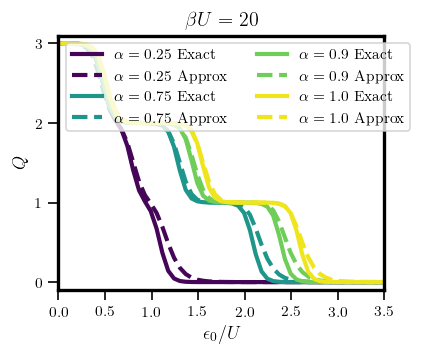

In [84]:
#
alphas = np.array(alphas, dtype=float)
fig, ax = plt.subplots(figsize=panel_figsize_for("1x2", "t"), constrained_layout=True)
for a in alphas:
    plt.plot(epsilon0, exact_curves[a]['Q'],c=color_of[a],label=fr'$\alpha={a}$ Exact',linewidth=2.5)
    plt.plot(epsilon0, mf_curves[a]['Q'], c=color_of[a],linestyle='--', label=fr'$\alpha={a}$ Approx',linewidth=2.5)
plt.legend(ncol=2)
plt.title(f'$\\beta U={beta}$')
plt.ylabel('$Q$')
plt.xlabel('$\epsilon_0/U$')
plt.tight_layout()
plt.xlim([0,3.5])
plt.ylim([-0.1,3.1])
plt.yticks([0,1,2,3])
#plt.savefig('Figures/Coulomb_staircase.svg')

[plateau]  h=+0.000000000000  F=-6.776e-20
5 {'h': 0.0, 'L': -6.77626583985639e-20, 'Lsq': 0.013671432373621013, 'Lpsq': 46.67332990707883, 'Lmsq': 15.557776635692944, 'F': -6.77626583985639e-20, 'converged': True, 'mode': 'plateau'}
[plateau]  h=+0.000000000000  F=-8.835e-29
10 {'h': 0.0, 'L': -8.835242138475332e-29, 'Lsq': 0.013740963133318367, 'Lpsq': 59.93239952033245, 'Lmsq': 19.97746650677749, 'F': -8.835242138475332e-29, 'converged': True, 'mode': 'plateau'}
[plateau]  h=+0.000000000000  F=+3.232e-19
15 {'h': 0.0, 'L': 3.2323054372729306e-19, 'Lsq': 0.013741227841628427, 'Lpsq': 59.99999471568014, 'Lmsq': 19.999998238560053, 'F': 3.2323054372729306e-19, 'converged': True, 'mode': 'plateau'}
[plateau]  h=+0.000000000000  F=+4.687e-19
20 {'h': 0.0, 'L': 4.686571100057371e-19, 'Lsq': 0.013741227862400581, 'Lpsq': 59.99999999999171, 'Lmsq': 19.99999999999723, 'F': 4.686571100057371e-19, 'converged': True, 'mode': 'plateau'}
[plateau]  h=+0.000000000000  F=-1.333e-19
25 {'h': 0.0, 'L

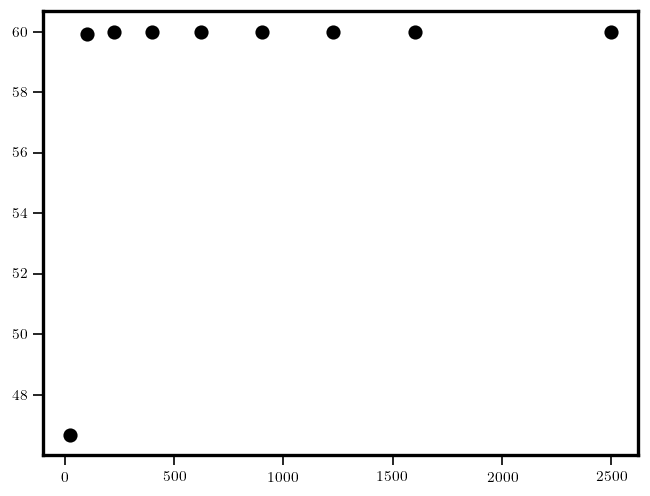

In [66]:
for M in [5,10,15,20,25,30,35,40,50]:
    rotor_solutions = solve_atomic_h(U=1, alpha=0.99, eps_0=0, beta=1e1, M_trunc= M, h_window=10.0, n_coarse=51, tol=1e-10, precompute = None,verbose=True, evaluate = True)
    print(M,rotor_solutions)
    plt.scatter(M**2,rotor_solutions['Lpsq'],c='k')

In [5]:
alphas = [0.25,0.75,0.9,1.]
M_trunc = 20
U = 1
exact_curves = {a: {'Q':[],'Qsq':[],'Npsq':[],'Nmsq':[]} for a in alphas}
mf_curves = {a: {'Q':[],'Qsq':[],'Npsq':[],'Nmsq':[]} for a in alphas}
epsilon0 = 0.
betas = np.logspace(-2,3,num=60)

for alpha in alphas:
    #precompute = build_rotor_precomp(U, alpha, M_trunc)
    for beta in betas:
        #
        rotor_solutions = solve_atomic_h(U, alpha, epsilon0, beta, M_trunc= M_trunc,
                   h_window=10.0, n_coarse=51, tol=1e-10,
                   verbose=True, evaluate = True)
        dat = three_valley_exact(alpha, beta = beta, epsilon0=epsilon0)
        exact_curves[alpha]['Q'].append(dat["Q"])
        exact_curves[alpha]['Qsq'].append(dat["Qsq"])
        exact_curves[alpha]['Npsq'].append(dat["Npsq"])
        exact_curves[alpha]['Nmsq'].append(dat["Nmsq"])
        mf_curves[alpha]['Q'].append(rotor_solutions['L'] +3.)
        mf_curves[alpha]['Qsq'].append(rotor_solutions['Lsq'] +6.*rotor_solutions['L'] +9.)
        if alpha < 1.:
            mf_curves[alpha]['Npsq'].append(rotor_solutions['Lpsq'])
            mf_curves[alpha]['Nmsq'].append(rotor_solutions['Lmsq'])

[plateau]  h=+0.000000000000  F=-2.776e-16
[plateau]  h=+0.000000000000  F=-5.274e-16
[plateau]  h=+0.000000000000  F=+1.665e-16
[plateau]  h=+0.000000000000  F=+6.939e-17
[plateau]  h=+0.000000000000  F=+2.845e-16
[plateau]  h=+0.000000000000  F=+3.608e-16
[plateau]  h=+0.000000000000  F=-6.245e-17
[plateau]  h=+0.000000000000  F=-2.654e-16
[plateau]  h=+0.000000000000  F=+1.485e-16
[plateau]  h=+0.000000000000  F=-2.649e-16
[plateau]  h=+0.000000000000  F=+8.365e-17
[plateau]  h=+0.000000000000  F=+1.859e-16
[plateau]  h=+0.000000000000  F=+9.068e-17
[plateau]  h=+0.000000000000  F=-9.673e-17
[plateau]  h=+0.000000000000  F=-2.402e-16
[plateau]  h=+0.000000000000  F=+1.951e-16
[plateau]  h=+0.000000000000  F=-1.293e-17
[plateau]  h=+0.000000000000  F=+7.162e-17
[plateau]  h=+0.000000000000  F=-1.046e-16
[plateau]  h=+0.000000000000  F=-6.697e-17
[plateau]  h=+0.000000000000  F=+3.212e-17
[plateau]  h=+0.000000000000  F=+7.333e-17
[plateau]  h=+0.000000000000  F=+1.200e-16
[plateau]  

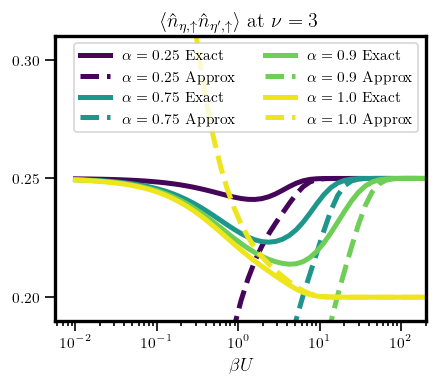

In [8]:
#
alphas = np.array(alphas, dtype=float)
fig, ax = plt.subplots(figsize=panel_figsize_for("1x2", "t"), constrained_layout=True)
for a in alphas:
    y1 = 0.25*(np.array((1./9)*np.array(exact_curves[a]['Qsq']) -(1./36)*np.array(exact_curves[a]['Npsq'])-(1./12)*np.array(exact_curves[a]['Nmsq'])))
    if a <1 :
        y2 = (0.25)*(np.array((1./9)*np.array(mf_curves[a]['Qsq']) -(1./36)*np.array(mf_curves[a]['Npsq'])-(1./12)*np.array(mf_curves[a]['Nmsq'])))
    else:
        y2 = (1./30)*(np.array(mf_curves[a]['Qsq']) - np.array(mf_curves[a]['Q']))
    plt.plot(betas, y1,c=color_of[a],label=fr'$\alpha={a}$ Exact')
    plt.plot(betas, y2, c=color_of[a],linestyle='--', label=fr'$\alpha={a}$ Approx')
#plt.legend(ncol=2)
plt.xscale('log')
plt.ylim([0.19,0.31])
plt.xlim([None,200])
plt.title('$\\langle \\hat{n}_{\\eta,\\uparrow}\\hat{n}_{\\eta\',\\uparrow} \\rangle $ at $\\nu=3$')
plt.xlabel('$\\beta U$')
plt.yticks([0.20,0.25,0.30])
#plt.ylabel('$Q$')
#plt.xlabel('$\epsilon_0/U$')
#plt.tight_layout()
#plt.xlim([0,3.5])
##lt.ylim([-0.1,3.1])
#plt.yticks([0,1,2,3])
plt.legend(ncol = 2)
plt.savefig('Figures/Dble.svg')

checking dependance of observables on truncation

In [5]:
alphas = [0.25,0.75,0.90,1.]
Ms = [10,15,20,25,30,35,40]
mf_curves = {a: {'Q':[],'Qsq':[],'Npsq':[],'Nmsq':[]} for a in alphas}
for M in Ms:
    for alpha  in alphas:
        rotor_solutions = solve_atomic_h(U=1, alpha=alpha, eps_0=0.75, beta= 20, M_trunc= M, h_window=10.0, n_coarse=51, tol=1e-10,verbose=True, evaluate = True)
        mf_curves[alpha]['Qsq'].append(rotor_solutions['Lsq'])
        if alpha < 1.:
            mf_curves[alpha]['Npsq'].append(rotor_solutions['Lpsq'])

[brentq ]  h=+0.704348988346  F=+8.371e-13
[brentq ]  h=+0.715514363345  F=+3.698e-11
[brentq ]  h=+0.715601915561  F=+1.413e-11
[brentq ]  h=+0.715835626586  F=+2.926e-12
[brentq ]  h=+0.704348988346  F=+8.371e-13
[brentq ]  h=+0.715514363345  F=+3.698e-11
[brentq ]  h=+0.715601915561  F=+1.413e-11
[brentq ]  h=+0.715835626586  F=+2.926e-12
[brentq ]  h=+0.704348988346  F=+8.371e-13
[brentq ]  h=+0.715514363345  F=+3.698e-11
[brentq ]  h=+0.715601915561  F=+1.413e-11
[brentq ]  h=+0.715835626586  F=+2.926e-12
[brentq ]  h=+0.704348988346  F=+8.371e-13
[brentq ]  h=+0.715514363345  F=+3.698e-11
[brentq ]  h=+0.715601915561  F=+1.413e-11
[brentq ]  h=+0.715835626586  F=+2.926e-12
[brentq ]  h=+0.704348988346  F=+8.371e-13
[brentq ]  h=+0.715514363345  F=+3.698e-11
[brentq ]  h=+0.715601915561  F=+1.413e-11
[brentq ]  h=+0.715835626586  F=+2.926e-12
[brentq ]  h=+0.704348988346  F=+8.371e-13
[brentq ]  h=+0.715514363345  F=+3.698e-11
[brentq ]  h=+0.715601915561  F=+1.413e-11
[brentq ]  

In [13]:
mf_curves[1]['Qsq']

[0.9868324900175562,
 0.9868324900175562,
 0.9868324900175562,
 0.9868324900175562,
 0.9868324900175562,
 0.9868324900175562,
 0.9868324900175562]

Text(0, 0.5, '$\\langle O \\rangle$')

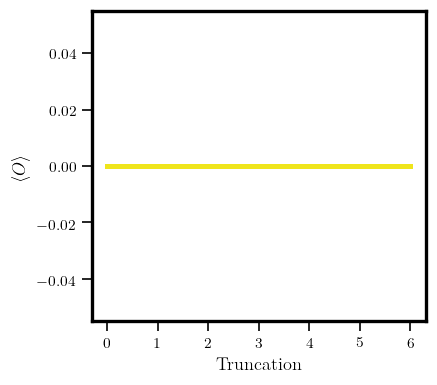

In [6]:
alphas = np.array(alphas, dtype=float)
fig, ax = plt.subplots(figsize=panel_figsize_for("1x2", "t"), constrained_layout=True)
for a in alphas:
    plt.plot(np.array(mf_curves[alpha]['Qsq']) - mf_curves[alpha]['Qsq'][-1],c=color_of[a],label=f'$\\alpha={a}$')
plt.xlabel('Truncation')
plt.ylabel('$\langle O \\rangle$')
